In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
from google.colab import files
uploaded = files.upload()

Saving retail_sales_dataset.csv to retail_sales_dataset (1).csv


In [57]:
df = pd.read_csv("retail_sales_dataset.csv")
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [30]:
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())

Shape of dataset: (1000, 9)

Columns:
 Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

Data types:
 Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

First 5 rows:
    Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3       

In [31]:
data_dict = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values,
    "Meaning": [
        "Unique transaction identifier",
        "Transaction date",
        "Unique customer identifier",
        "Customer gender",
        "Customer age",
        "Product category purchased",
        "Number of units purchased",
        "Price of one unit",
        "Total transaction amount"
    ]
})

data_dict

,Column Name,Data Type,Meaning
0,Transaction ID,int64,Unique transaction identifier
1,Date,object,Transaction date
2,Customer ID,object,Unique customer identifier
3,Gender,object,Customer gender
4,Age,int64,Customer age
5,Product Category,object,Product category purchased
6,Quantity,int64,Number of units purchased
7,Price per Unit,int64,Price of one unit
8,Total Amount,int64,Total transaction amount


In [32]:
print("Missing values in each column:\n")
print(df.isnull().sum())

Missing values in each column:

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [33]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Transaction IDs:", df["Transaction ID"].duplicated().sum())

Duplicate rows: 0
Duplicate Transaction IDs: 0


In [34]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
print(df.dtypes)

Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object


In [35]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
print(df.dtypes)

Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object


In [36]:
df["Calculated Total"] = df["Quantity"] * df["Price per Unit"]

mismatch = df[df["Total Amount"] != df["Calculated Total"]]
print("Rows where Total Amount does not match Quantity * Price per Unit:")
print(mismatch.shape[0])

mismatch.head()

Rows where Total Amount does not match Quantity * Price per Unit:
0


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Calculated Total


In [37]:
print("Unique Gender values:", df["Gender"].unique())
print("Unique Product Categories:", df["Product Category"].unique())

Unique Gender values: ['Male' 'Female']
Unique Product Categories: ['Beauty' 'Clothing' 'Electronics']


In [38]:
print(df[["Age", "Quantity", "Price per Unit", "Total Amount"]].describe())

              Age     Quantity  Price per Unit  Total Amount
count  1000.00000  1000.000000     1000.000000   1000.000000
mean     41.39200     2.514000      179.890000    456.000000
std      13.68143     1.132734      189.681356    559.997632
min      18.00000     1.000000       25.000000     25.000000
25%      29.00000     1.000000       30.000000     60.000000
50%      42.00000     3.000000       50.000000    135.000000
75%      53.00000     4.000000      300.000000    900.000000
max      64.00000     4.000000      500.000000   2000.000000


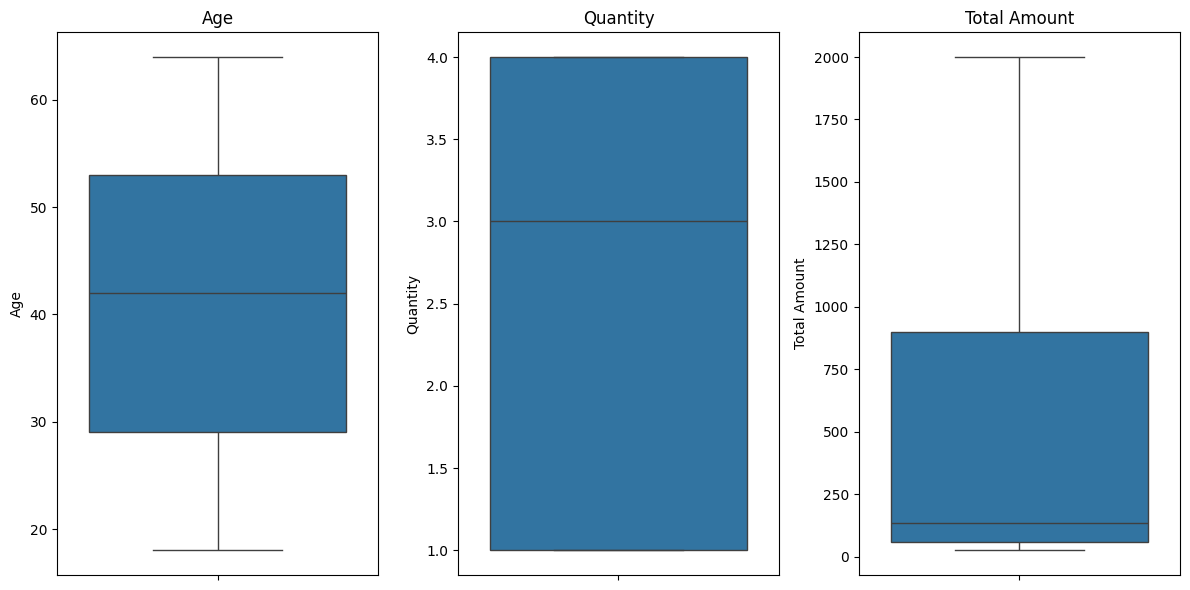

In [39]:
plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
sns.boxplot(y=df["Age"])
plt.title("Age")

plt.subplot(1,3,2)
sns.boxplot(y=df["Quantity"])
plt.title("Quantity")

plt.subplot(1,3,3)
sns.boxplot(y=df["Total Amount"])
plt.title("Total Amount")

plt.tight_layout()
plt.show()

In [41]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['transaction_id', 'date', 'customer_id', 'gender', 'age',
       'product_category', 'quantity', 'price_per_unit', 'total_amount',
       'calculated_total'],
      dtype='object')

In [42]:
df["gender"] = df["gender"].str.strip().str.title()
df["product_category"] = df["product_category"].str.strip().str.title()

print(df["gender"].unique())
print(df["product_category"].unique())

['Male' 'Female']
['Beauty' 'Clothing' 'Electronics']


In [43]:
df = df.drop_duplicates()
df = df.drop_duplicates(subset=["transaction_id"])
print("New shape after removing duplicates:", df.shape)

New shape after removing duplicates: (1000, 10)


In [44]:
df["gender"] = df["gender"].fillna("Unknown")
df["product_category"] = df["product_category"].fillna("Unknown")
df["age"] = df["age"].fillna(df["age"].median())
df["quantity"] = df["quantity"].fillna(df["quantity"].median())
df["price_per_unit"] = df["price_per_unit"].fillna(df["price_per_unit"].median())
df["total_amount"] = df["total_amount"].fillna(df["quantity"] * df["price_per_unit"])

In [45]:
df["total_amount"] = df["quantity"] * df["price_per_unit"]

In [46]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.month_name()
df["day_name"] = df["date"].dt.day_name()

In [47]:
bins = [0, 18, 25, 35, 45, 60, 100]
labels = ["0-18", "19-25", "26-35", "36-45", "46-60", "60+"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=True)

In [48]:
df["spending_level"] = pd.cut(
    df["total_amount"],
    bins=[0, 100, 500, 1000, 5000],
    labels=["Low", "Medium", "High", "Very High"]
)

In [49]:
print(df.info())
print(df.isnull().sum())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    1000 non-null   int64         
 1   date              1000 non-null   datetime64[ns]
 2   customer_id       1000 non-null   object        
 3   gender            1000 non-null   object        
 4   age               1000 non-null   int64         
 5   product_category  1000 non-null   object        
 6   quantity          1000 non-null   int64         
 7   price_per_unit    1000 non-null   int64         
 8   total_amount      1000 non-null   int64         
 9   calculated_total  1000 non-null   int64         
 10  year              1000 non-null   int32         
 11  month             1000 non-null   int32         
 12  month_name        1000 non-null   object        
 13  day_name          1000 non-null   object        
 14  age_group         1000 no

In [50]:
df.to_csv("retail_sales_cleaned.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [52]:
data_dict_cleaned = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values,
    "Description": [
        "Unique transaction identifier",
        "Transaction date",
        "Unique customer identifier",
        "Customer gender",
        "Customer age",
        "Purchased product category",
        "Purchased quantity",
        "Unit price of product",
        "Final total amount",
        "Calculated total amount based on quantity and price per unit",
        "Transaction year",
        "Transaction month number",
        "Transaction month name",
        "Transaction day name",
        "Customer age group",
        "Customer spending level"
    ]
})

data_dict_cleaned.to_csv("data_dictionary.csv", index=False)
data_dict_cleaned

,Column Name,Data Type,Description
0,transaction_id,int64,Unique transaction identifier
1,date,datetime64[ns],Transaction date
2,customer_id,object,Unique customer identifier
3,gender,object,Customer gender
4,age,int64,Customer age
5,product_category,object,Purchased product category
6,quantity,int64,Purchased quantity
7,price_per_unit,int64,Unit price of product
8,total_amount,int64,Final total amount
9,calculated_total,int64,Calculated total amount based on quantity and ...


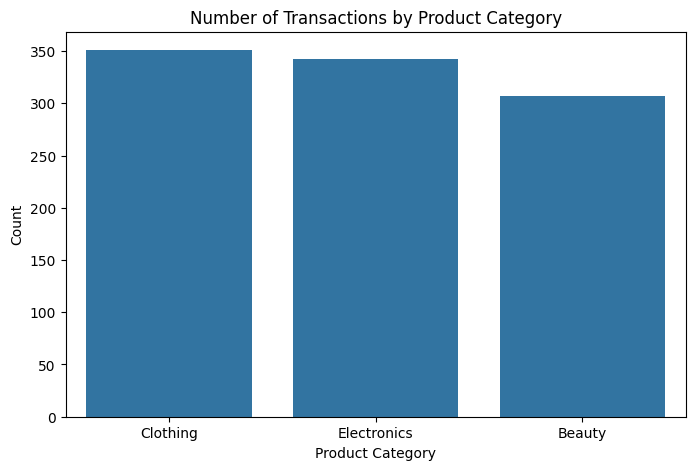

In [54]:
plt.figure(figsize=(8,5))
sns.barplot(x=df["product_category"].value_counts().index,
            y=df["product_category"].value_counts().values)
plt.title("Number of Transactions by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.show()

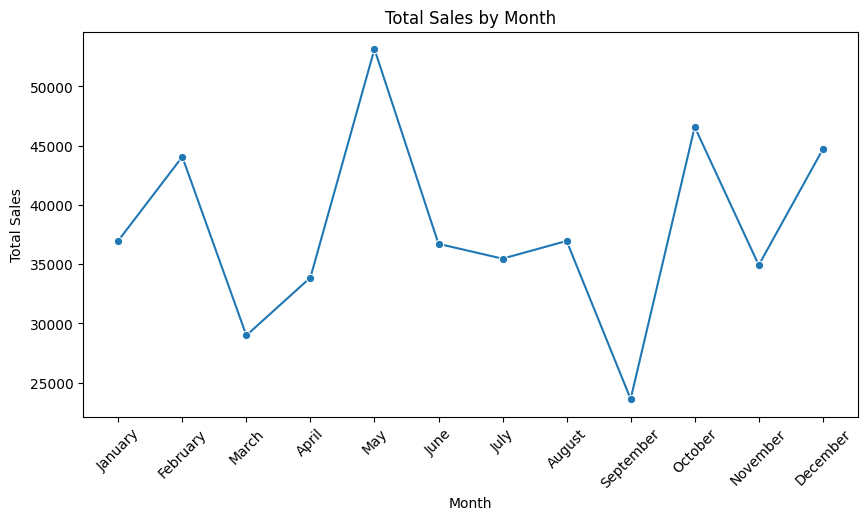

In [55]:
monthly_sales = df.groupby("month_name")["total_amount"].sum().reset_index()

month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
monthly_sales["month_name"] = pd.Categorical(monthly_sales["month_name"], categories=month_order, ordered=True)
monthly_sales = monthly_sales.sort_values("month_name")

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_sales, x="month_name", y="total_amount", marker="o")
plt.title("Total Sales by Month")
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

In [58]:
df = pd.read_csv("/content/retail_sales_cleaned.csv")
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   transaction_id    1000 non-null   int64 
 1   date              1000 non-null   object
 2   customer_id       1000 non-null   object
 3   gender            1000 non-null   object
 4   age               1000 non-null   int64 
 5   product_category  1000 non-null   object
 6   quantity          1000 non-null   int64 
 7   price_per_unit    1000 non-null   int64 
 8   total_amount      1000 non-null   int64 
 9   calculated_total  1000 non-null   int64 
 10  year              1000 non-null   int64 
 11  month             1000 non-null   int64 
 12  month_name        1000 non-null   object
 13  day_name          1000 non-null   object
 14  age_group         1000 non-null   object
 15  spending_level    1000 non-null   object
dtypes: int64(8), object(8)
memory usage: 125.1+ KB


,0
transaction_id,0
date,0
customer_id,0
gender,0
age,0
product_category,0
quantity,0
price_per_unit,0
total_amount,0
calculated_total,0


In [59]:
from google.colab import files
files.download("retail_sales_cleaned.csv")
files.download("data_dictionary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>